In [30]:
from sklearn.model_selection import train_test_split
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import importlib
import data_loader
import joblib
importlib.reload(data_loader)
from data_loader import load_data
from feature_extraction import extract_hog_features

In [25]:
DATASET_PATH = "../data/archive"
POSITIVE_PATH = os.path.join(DATASET_PATH, "Positive")
NEGATIVE_PATH = os.path.join(DATASET_PATH, "Negative")

images, labels = load_data(POSITIVE_PATH, NEGATIVE_PATH)

print(f"Using {len(images)} images for this test.")


Using 1000 images for this test.


In [ ]:
DATASET_PATH = "../data/archive"
POSITIVE_PATH = os.path.join(DATASET_PATH, "Positive")
NEGATIVE_PATH = os.path.join(DATASET_PATH, "Negative")


def train_svm():
    images, labels = load_data(POSITIVE_PATH, NEGATIVE_PATH, 2000)  # Limit to first 2000 images for testing

    X = extract_hog_features(images)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        labels,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=labels
    )

    svm = SVC(kernel="rbf", C=1, gamma="scale")

    svm.fit(X_train, y_train)

    joblib.dump(svm, "../models/svm_rbf_hog.pkl")

    y_pred = svm.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
    
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix - HOG + SVM")

    plt.show()
    return svm

# if __name__ == "__main__":

Test Accuracy: 0.9850
              precision    recall  f1-score   support

    Negative       0.98      0.99      0.99       400
    Positive       0.99      0.97      0.98       400

    accuracy                           0.98       800
   macro avg       0.99      0.98      0.98       800
weighted avg       0.99      0.98      0.98       800



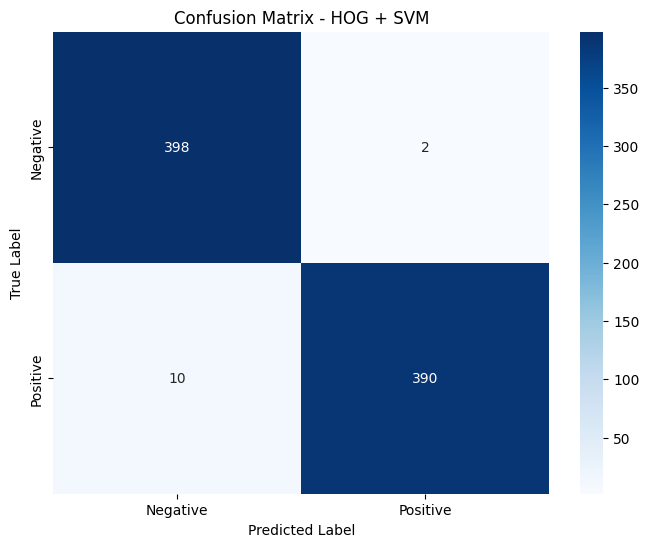

In [32]:
train_svm()